# StegoGAN: A GAN-Based Framework for Steganography Using LSB Embedding

# 1. Introduction

## Image Steganography

Image steganography is the technique of embedding secret information (text, image, or binary data) in a digital image without the viewer being aware of the hidden information. The main objective is to have secure and hidden communication. In contrast to encryption, which hides the message content, steganography conceals the message that is communicated.


## Least Significant Bit (LSB) Method

LSB is one of the most straightforward and well-known steganographic methods. It operates by modifying the least significant bits of the cover image's pixels in order to hide confidential data. For instance, modifying the last bit in an 8-bit pixel value will barely be noticeable visually.

# 2. Methods

## Least Significant Bit (LSB) Method

LSB is one of the most straightforward and well-known steganographic methods. It operates by modifying the least significant bits of the cover image's pixels in order to hide confidential data. For instance, modifying the last bit in an 8-bit pixel value will barely be noticeable visually.

## Generative Adversarial Networks (GANs)

GANs are a type of deep learning architecture discovered by Ian Goodfellow in 2014 and consist of two competing neural networks that engage in a zero-sum game.

### 1. Generator (G):
- Trained to produce stego images from cover images and hidden information.

- Its aim is to hide information in a way that the image will appear normal.

### 2. Discriminator (D):
- Trained to differentiate between original (cover) images and copied (stego) images.
-  Attempts to deceive the generator by identifying concealed patterns.

## Working Mechanism

### 1. Initial Setup:

- The generator creates stego images.

- The discriminator evaluates both real (cover) and fake (stego) images.

### 2. Adversarial Training Loop:

- The discriminator is trained to maximize its ability to distinguish real from fake.

- The generator is trained to minimize the discriminator’s ability to tell the difference.

Objective functions:
- Generator Loss: LG = −log(D(G(z)))

- Discriminator Loss: LD = −[log(D(x))+log(1−D(G(z)))]

### 3. Convergence:
- Ideally, the generator becomes so good that the discriminator can only guess at random (i.e., outputs 0.5 for any image).

- At equilibrium: D(x)=0.5, meaning perfect deception by the generator.

# 3. Implementation:

## 1. Importing necessary libraries

In [130]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [131]:
import cv2
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision

## 2. Text to Bitmap Conversion

To hide text messages within images, we first need to convert the text into a bitmap (binary format). Each character of the text is converted to its 8-bit binary representation and padded to fit within a 64x64 grid.

Below is the code to convert text to a bitmap and vice versa:

In [135]:
# ---------- Text <-> Bitmap ----------
# Function to convert text to bitmap format (binary image representation)
def text_to_bitmap(text, width=64, height=64):
    # Convert text to binary (8-bit per character) and add 8 bits as padding
    binary = ''.join([format(ord(c), '08b') for c in text]) + '00000000'
    # Ensure the binary string has enough bits to fit in the given image dimensions (width * height)
    binary = (binary + '0' * (width * height))[:width * height]
    # Convert the binary string into a numpy array and reshape it into a 2D image
    data = np.array(list(binary), dtype=np.uint8).reshape((height, width))
    # Convert numpy array into a tensor and add batch dimension
    return torch.tensor(data, dtype=torch.float32).unsqueeze(0)

# Function to convert bitmap (binary image) back to text
def bitmap_to_text(bitmap):
    # Flatten the bitmap and convert to binary string
    flat = bitmap.flatten().tolist()
    bits = ''.join([str(int(x > 0.5)) for x in flat])  # Consider pixels > 0.5 as 1
    # Convert each 8 bits to a character
    chars = [chr(int(bits[i:i+8], 2)) for i in range(0, len(bits), 8)]
    # Remove null characters and return the decoded message
    return ''.join([c for c in chars if c != '\x00'])

## 3. Dataset Setup

We create a custom dataset that pairs cover images with corresponding secret messages. These images are then transformed (e.g., random rotations, color jitter) to make the model more robust.

In [138]:
# ---------- Dataset ----------
# Custom dataset to load cover images and secret messages
class StegoTextDataset(Dataset):
    def __init__(self, cover_images, messages, transform):
        self.cover_images = cover_images  # List of cover image paths
        self.messages = messages          # Corresponding secret messages
        self.transform = transform        # Data transformations (e.g., rotation, jitter)

    def __len__(self):
        return len(self.cover_images)    # Number of items in the dataset

    def __getitem__(self, idx):
        # Open the cover image, resize, and apply transformations
        cover = Image.open(self.cover_images[idx]).convert("RGB").resize((64, 64))
        cover = self.transform(cover)  # Apply transformations
        # Convert the corresponding message to a bitmap
        secret = text_to_bitmap(self.messages[idx])
        return cover, secret  # Return transformed cover image and secret bitmap

## 4. Model Architecture

The `HidingNet` takes a cover image and a secret message (in bitmap format) as input and outputs a stego image with the message embedded. `RevealNet` takes the stego image as input and recovers the hidden message.

In [141]:
# ---------- Models ----------
# Hiding network (encoder) - combines cover image with secret message to produce stego image
class HidingNet(nn.Module):
    def __init__(self):
        super(HidingNet, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 64, 3, 1, 1),  # 4 input channels: 3 for cover + 1 for secret
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, 1, 1),  # Output 3 channels for RGB stego image
            nn.Sigmoid()  # Sigmoid to ensure pixel values are in [0, 1]
        )

    def forward(self, cover, secret):
        return self.net(torch.cat([cover, secret], dim=1))  # Concatenate cover and secret along the channel axis

# Reveal network (decoder) - recovers the secret from the stego image
class RevealNet(nn.Module):
    def __init__(self):
        super(RevealNet, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),  # 3 input channels for RGB stego image
            nn.ReLU(),
            nn.Conv2d(64, 1, 3, 1, 1),  # Output 1 channel: the recovered secret
            nn.Sigmoid()
        )

    def forward(self, stego):
        return self.net(stego)  # Process stego image to reveal secret

## 5. Preprocessing Utilities

Preprocessing techniques such as image filtering and edge detection can help improve the performance of the model. Below are the functions for applying an edge detection filter and a sharpening filter to the images.

In [144]:
# ---------- Preprocessing Utilities ----------
# Function to apply sharpening filter to the input image tensor
def apply_filter(image_tensor):
    kernel = torch.tensor([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    kernel = kernel.repeat(3, 1, 1, 1).to(image_tensor.device)  # Repeat kernel for RGB channels
    return torch.nn.functional.conv2d(image_tensor, kernel, padding=1, groups=3)

# Function to apply edge detection using Sobel filters
def edge_detect(image_tensor):
    sobel_x = torch.tensor([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    sobel_y = torch.tensor([[-1, -2, -1],
                            [0, 0, 0],
                            [1, 2, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    sobel_x = sobel_x.repeat(3, 1, 1, 1).to(image_tensor.device)
    sobel_y = sobel_y.repeat(3, 1, 1, 1).to(image_tensor.device)
    # Apply Sobel filters in X and Y directions and compute magnitude
    edge_x = torch.nn.functional.conv2d(image_tensor, sobel_x, padding=1, groups=3)
    edge_y = torch.nn.functional.conv2d(image_tensor, sobel_y, padding=1, groups=3)
    edges = torch.sqrt(edge_x**2 + edge_y**2)  # Combine X and Y gradients
    return edges

## 6. Visualization

In [147]:
# Function to display original, cover, stego, and recovered images
def show_four_images(original, cover, stego, recovered):
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    
    # Show the images with appropriate titles and hide axes
    axs[0].imshow(original)
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    axs[1].imshow(cover.squeeze().permute(1, 2, 0).cpu().numpy())
    axs[1].set_title("Cover Image (Transformed)")
    axs[1].axis('off')

    axs[2].imshow(stego.squeeze().permute(1, 2, 0).detach().cpu().numpy())
    axs[2].set_title("Stego Image")
    axs[2].axis('off')

    axs[3].imshow(recovered.squeeze().detach().cpu().numpy(), cmap='gray')
    axs[3].set_title("Recovered Secret")
    axs[3].axis('off')

    plt.tight_layout()
    plt.show()

In [149]:
# ---------- Setup ----------
# Set device to CUDA if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define paths to cover images and the secret messages
cover_images = ['/Users/ujaspatel/Downloads/AI688_Project_Patel_Ujas/Brooklyn bridge.png']
messages = ['This is a hidden message!']

# Data augmentation transformations to apply to cover images
transform = transforms.Compose([
    transforms.RandomRotation(15),  # Randomly rotate cover images
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # Apply color jittering
    transforms.ToTensor()  # Convert image to tensor format
])

# Prepare dataset and dataloader
dataset = StegoTextDataset(cover_images, messages, transform)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

# Instantiate models
hiding_net = HidingNet().to(device)
reveal_net = RevealNet().to(device)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(list(hiding_net.parameters()) + list(reveal_net.parameters()), lr=1e-3)

## 7. Training Loop

The model is train using a loop that compares results with and without preprocessing. We will visualize the losses at each step for both approaches and analyze the impact of preprocessing.

### Training with Preprocessing:

In [152]:
# Track losses for visualization and analysis
stage_losses_with_preprocessing = []
recover_losses_with_preprocessing = []
total_losses_with_preprocessing = []

# Training loop for 5 epochs with preprocessing applied
for epoch in range(5):
    for i, (cover, secret) in enumerate(loader):
        cover, secret = cover.to(device), secret.to(device)
        cover = apply_filter(cover)  # Apply preprocessing filter

        stego = hiding_net(cover, secret)  # Generate stego image
        recovered = reveal_net(stego)  # Recover the secret from the stego image

        # Calculate losses for the stego generation and recovery
        stage_loss = criterion(stego, cover)  # Loss for generating stego
        recover_loss = criterion(recovered, secret)  # Loss for recovering secret
        total_loss = stage_loss + recover_loss  # Total loss

        # Append losses for analysis
        stage_losses_with_preprocessing.append(stage_loss.item())
        recover_losses_with_preprocessing.append(recover_loss.item())
        total_losses_with_preprocessing.append(total_loss.item())

        optimizer.zero_grad()
        total_loss.backward()  # Backpropagate loss
        optimizer.step()  # Update model parameters

        print(f"[With Preprocessing] Epoch {epoch}, Step {i} | Total: {total_loss.item():.4f}, Stage: {stage_loss.item():.4f}, Recover: {recover_loss.item():.4f}")

        if epoch == 4:
            last_cover_with_preprocessing = cover
            last_stego_with_preprocessing = stego
            last_recovered_with_preprocessing = recovered

[With Preprocessing] Epoch 0, Step 0 | Total: 0.4086, Stage: 0.1437, Recover: 0.2649
[With Preprocessing] Epoch 1, Step 0 | Total: 0.4526, Stage: 0.2086, Recover: 0.2440
[With Preprocessing] Epoch 2, Step 0 | Total: 0.4774, Stage: 0.2544, Recover: 0.2230
[With Preprocessing] Epoch 3, Step 0 | Total: 0.4390, Stage: 0.2364, Recover: 0.2026
[With Preprocessing] Epoch 4, Step 0 | Total: 0.3030, Stage: 0.1197, Recover: 0.1833


### Training without Preprocessing:

In [155]:
# Similar loop for training without preprocessing (just cover and secret images)
stage_losses_without_preprocessing = []
recover_losses_without_preprocessing = []
total_losses_without_preprocessing = []

for epoch in range(5):
    for i, (cover, secret) in enumerate(loader):
        cover, secret = cover.to(device), secret.to(device)

        stego = hiding_net(cover, secret)
        recovered = reveal_net(stego)

        stage_loss = criterion(stego, cover)
        recover_loss = criterion(recovered, secret)
        total_loss = stage_loss + recover_loss

        stage_losses_without_preprocessing.append(stage_loss.item())
        recover_losses_without_preprocessing.append(recover_loss.item())
        total_losses_without_preprocessing.append(total_loss.item())

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        print(f"[Without Preprocessing] Epoch {epoch}, Step {i} | Total: {total_loss.item():.4f}, Stage: {stage_loss.item():.4f}, Recover: {recover_loss.item():.4f}")

        if epoch == 4:
            last_cover_without_preprocessing = cover
            last_stego_without_preprocessing = stego
            last_recovered_without_preprocessing = recovered

[Without Preprocessing] Epoch 0, Step 0 | Total: 0.2234, Stage: 0.0617, Recover: 0.1617
[Without Preprocessing] Epoch 1, Step 0 | Total: 0.2034, Stage: 0.0587, Recover: 0.1447
[Without Preprocessing] Epoch 2, Step 0 | Total: 0.1646, Stage: 0.0413, Recover: 0.1233
[Without Preprocessing] Epoch 3, Step 0 | Total: 0.1655, Stage: 0.0603, Recover: 0.1051
[Without Preprocessing] Epoch 4, Step 0 | Total: 0.1309, Stage: 0.0448, Recover: 0.0861


## 8. Visualization of Results

We will visualize the cover images, stego images, and recovered secrets from both the training with and without preprocessing.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.564706..2.4313726].


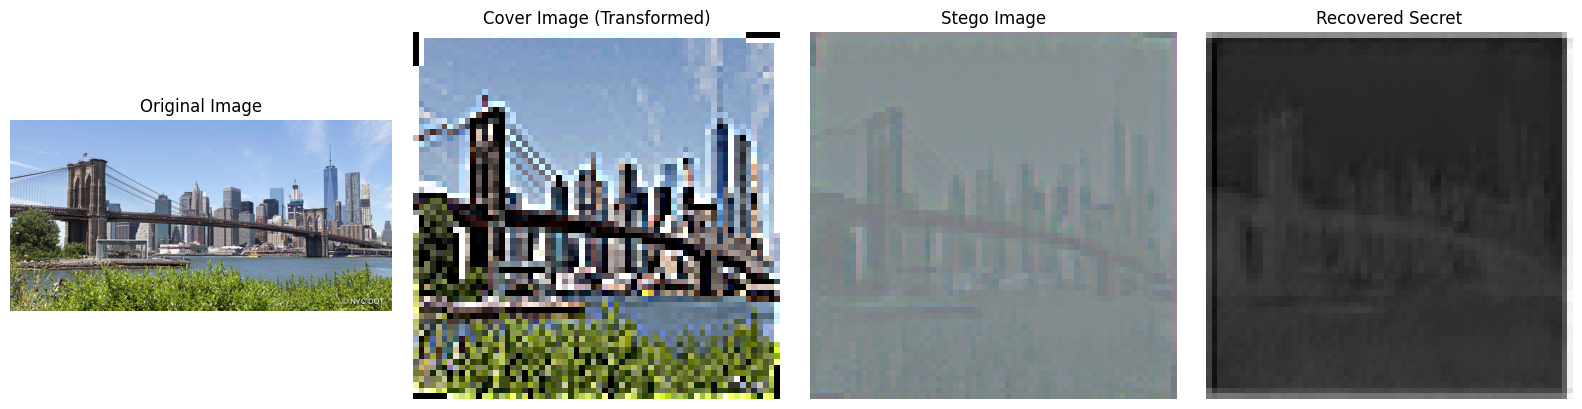

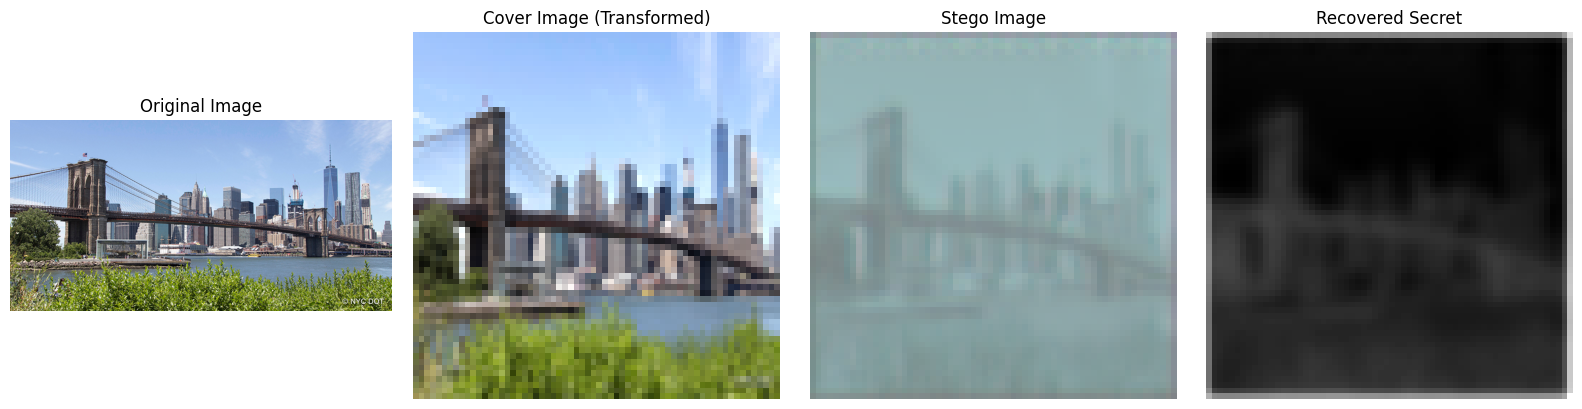

In [158]:
# ---------- Show Results ----------
# Load original image to display alongside processed images
original_image = cv2.imread(cover_images[0])
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Display images for both cases: with and without preprocessing
show_four_images(original_image, last_cover_with_preprocessing, last_stego_with_preprocessing, last_recovered_with_preprocessing)
show_four_images(original_image, last_cover_without_preprocessing, last_stego_without_preprocessing, last_recovered_without_preprocessing)


## 9. Loss Plots

Let's visualize the training losses for both approaches to compare their performance.

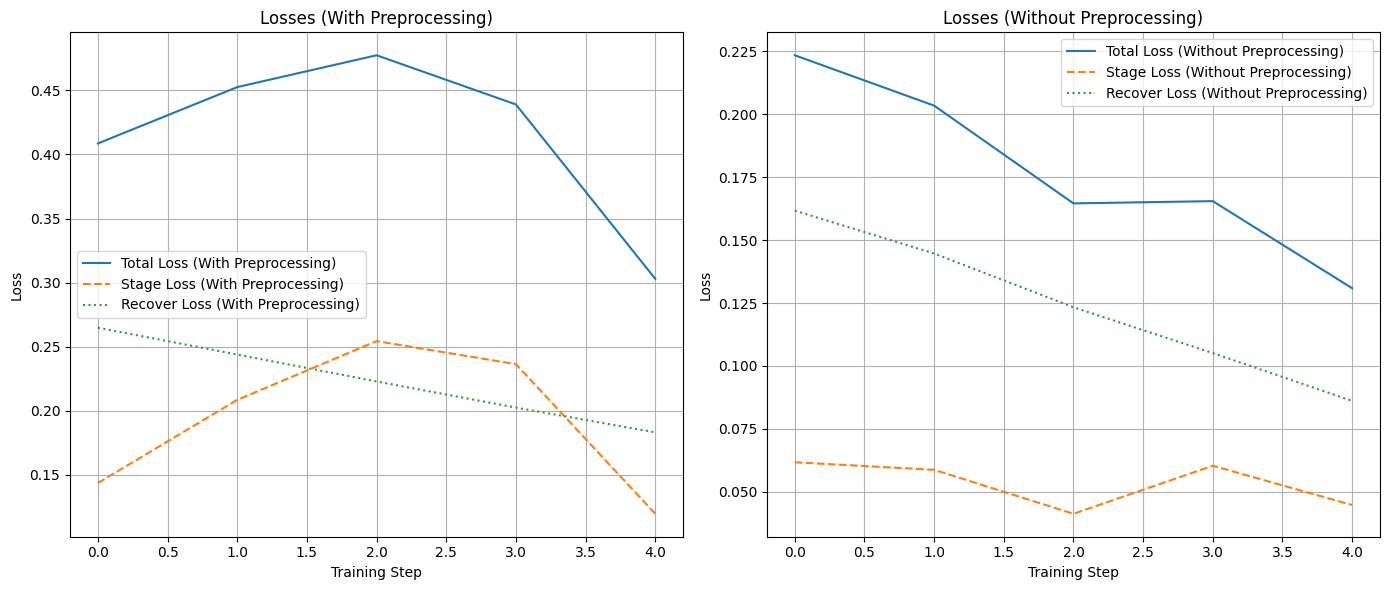

In [161]:
# ---------- Plot All Losses ----------
plt.figure(figsize=(14, 6))

# Plot losses for training with preprocessing
plt.subplot(1, 2, 1)
plt.plot(total_losses_with_preprocessing, label="Total Loss (With Preprocessing)", linestyle='-')
plt.plot(stage_losses_with_preprocessing, label="Stage Loss (With Preprocessing)", linestyle='--')
plt.plot(recover_losses_with_preprocessing, label="Recover Loss (With Preprocessing)", linestyle=':')
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Losses (With Preprocessing)")
plt.legend()
plt.grid(True)

# Plot losses for training without preprocessing
plt.subplot(1, 2, 2)
plt.plot(total_losses_without_preprocessing, label="Total Loss (Without Preprocessing)", linestyle='-')
plt.plot(stage_losses_without_preprocessing, label="Stage Loss (Without Preprocessing)", linestyle='--')
plt.plot(recover_losses_without_preprocessing, label="Recover Loss (Without Preprocessing)", linestyle=':')
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Losses (Without Preprocessing)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 10. LSB Encoding/Decoding

In addition to GAN-based steganography, we will also demonstrate how to use Least Significant Bit (LSB) encoding to hide and recover messages in an image. This method can serve as an additional technique for comparison.

In [164]:
# Functions for Least Significant Bit (LSB) encoding and decoding
def message_to_binary(message):
    return ''.join([format(ord(i), '08b') for i in message])

def binary_to_message(binary):
    chars = [binary[i:i+8] for i in range(0, len(binary), 8)]
    return ''.join([chr(int(char, 2)) for char in chars if int(char, 2) != 0])

# Function to encode a message in the least significant bits of an image
def encode_lsb(image_path, message, output_path):
    image = cv2.imread(image_path)
    binary_msg = message_to_binary(message) + '1111111111111110'  # Add EOF signal
    data_index = 0

    for row in image:
        for pixel in row:
            for i in range(3):
                if data_index < len(binary_msg):
                    pixel[i] = np.uint8((int(pixel[i]) & ~1) | int(binary_msg[data_index]))
                    data_index += 1

    cv2.imwrite(output_path, image)  # Save the image with encoded message
    print(f"✅ Message encoded and saved to {output_path}")

# Function to decode a hidden message from an image using LSB technique
def decode_lsb(image_path):
    image = cv2.imread(image_path)
    binary_data = ''

    for row in image:
        for pixel in row:
            for i in range(3):
                binary_data += str(pixel[i] & 1)

    eof = '1111111111111110'
    end_idx = binary_data.find(eof)  # Find end-of-file marker
    if end_idx != -1:
        binary_data = binary_data[:end_idx]  # Trim the binary string at EOF
    else:
        print("❌ No EOF found. Message may be missing.")

    return binary_to_message(binary_data)

# ---------- LSB Test ----------
# Test LSB encoding and decoding
input_image = "/Users/ujaspatel/Downloads/AI688_Project_Patel_Ujas/Brooklyn bridge.png"
output_image = "/Users/ujaspatel/Downloads/AI688_Project_Patel_Ujas/encoded_image.png"
secret_message = "This is my secret and important message!"

encode_lsb(input_image, secret_message, output_image)  # Encode the message
decoded_message = decode_lsb(output_image)  # Decode the message
print("📥 Decoded message from LSB:", decoded_message)

✅ Message encoded and saved to /Users/ujaspatel/Downloads/AI688_Project_Patel_Ujas/encoded_image.png
📥 Decoded message from LSB: This is my secret and important message!


## Image Steganography with GANs (CIFAR-10 Dataset)

100%|████████████████████████████████████████| 170M/170M [00:10<00:00, 16.2MB/s]


Epoch [1/5], Step [0], Loss D: 1.3860, Loss G: 0.7979
Epoch [1/5], Step [100], Loss D: 1.3761, Loss G: 0.9344
Epoch [1/5], Step [200], Loss D: 1.4007, Loss G: 0.8086
Epoch [1/5], Step [300], Loss D: 1.3836, Loss G: 0.9371
Epoch [1/5], Step [400], Loss D: 1.1334, Loss G: 1.0953
Epoch [1/5], Step [500], Loss D: 1.3981, Loss G: 0.6902
Epoch [1/5], Step [600], Loss D: 1.3238, Loss G: 0.7309
Epoch [1/5], Step [700], Loss D: 1.3987, Loss G: 0.8138
Epoch [2/5], Step [0], Loss D: 1.3887, Loss G: 0.7100
Epoch [2/5], Step [100], Loss D: 1.3845, Loss G: 0.7097
Epoch [2/5], Step [200], Loss D: 1.3659, Loss G: 0.7215
Epoch [2/5], Step [300], Loss D: 1.3740, Loss G: 0.7206
Epoch [2/5], Step [400], Loss D: 1.3955, Loss G: 0.6945
Epoch [2/5], Step [500], Loss D: 1.3702, Loss G: 0.7313
Epoch [2/5], Step [600], Loss D: 1.3584, Loss G: 0.7425
Epoch [2/5], Step [700], Loss D: 1.3609, Loss G: 0.7412
Epoch [3/5], Step [0], Loss D: 1.3932, Loss G: 0.7168
Epoch [3/5], Step [100], Loss D: 1.3665, Loss G: 0.725

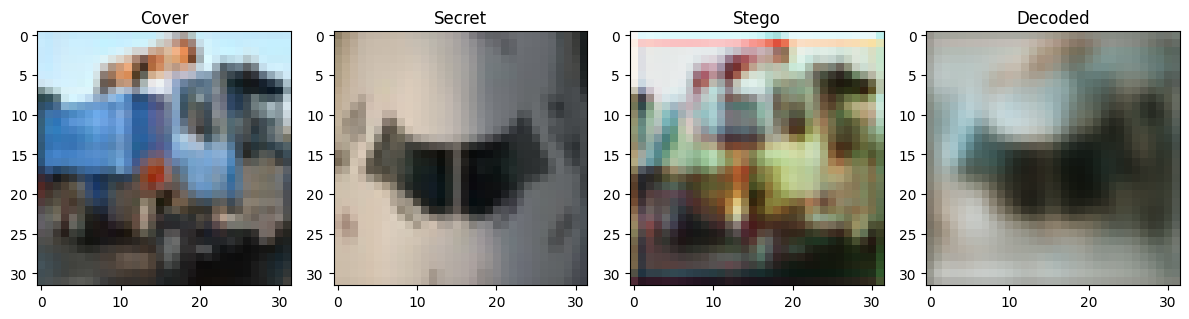

In [94]:
# Image Steganography with GANs (CIFAR-10 Dataset)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Config
BATCH_SIZE = 64
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Transform
transform = transforms.Compose([
    transforms.ToTensor(),
])

# CIFAR-10 Dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Define Models
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(6, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, cover, secret):
        x = torch.cat([cover, secret], dim=1)  # (B, 6, H, W)
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, stego):
        return self.net(stego)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Initialize models
encoder = Encoder().to(DEVICE)
decoder = Decoder().to(DEVICE)
discriminator = Discriminator().to(DEVICE)

# Losses and Optimizers
mse_loss = nn.MSELoss()
bce_loss = nn.BCELoss()

opt_enc_dec = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
opt_disc = optim.Adam(discriminator.parameters(), lr=1e-4)

# Training Loop
for epoch in range(EPOCHS):
    for i, (images, _) in enumerate(train_loader):
        cover = images.to(DEVICE)
        secret = images.flip(0).to(DEVICE)  # Just using flipped batch as secret for demo

        # Encode
        stego = encoder(cover, secret)

        # Decode
        decoded_secret = decoder(stego)

        # Train Discriminator
        real_labels = torch.ones(cover.size(0), 1).to(DEVICE)
        fake_labels = torch.zeros(cover.size(0), 1).to(DEVICE)

        disc_real = discriminator(cover)
        disc_fake = discriminator(stego.detach())

        loss_disc = bce_loss(disc_real, real_labels) + bce_loss(disc_fake, fake_labels)

        opt_disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        # Train Encoder + Decoder
        disc_fake = discriminator(stego)

        loss_adv = bce_loss(disc_fake, real_labels)
        loss_rec = mse_loss(decoded_secret, secret)
        loss_stego_sim = mse_loss(stego, cover)

        loss_enc_dec = loss_adv + loss_rec + 0.5 * loss_stego_sim

        opt_enc_dec.zero_grad()
        loss_enc_dec.backward()
        opt_enc_dec.step()

        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{i}], Loss D: {loss_disc.item():.4f}, Loss G: {loss_enc_dec.item():.4f}")

# Visualization
encoder.eval()
decoder.eval()

cover, _ = next(iter(train_loader))
cover = cover.to(DEVICE)
secret = cover.flip(0).to(DEVICE)
stego = encoder(cover, secret)
decoded = decoder(stego)

# Display
def imshow(img, title=""):
    npimg = img.detach().cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    

plt.figure(figsize=(12, 4))
for i, img in enumerate([cover[0], secret[0], stego[0], decoded[0]]):
    plt.subplot(1, 4, i+1)
    title = ['Cover', 'Secret', 'Stego', 'Decoded'][i]
    imshow(img, title)
plt.tight_layout()
plt.show()

# 4. Applications

- Secure Communication: Send sensitive data without declaring its presence.

- Digital Watermarking: Protect intellectual property by hiding copyright data.

- Covert Messaging: Convey information in surveillance-rich environments.

- Authentication: Implant ID or authentication data in documents/images.

- Military and Intelligence: Securely exchange classified data.


# 5. Ethical Implications

### Positive Aspects
- Respects privacy and freedom of expression.

- Improves cybersecurity and secure data exchange.

### Risks and Concerns
- Malicious use for criminal purpose (e.g., concealing malware).

- Untraceability: Abuse is difficult to detect without advanced steganalysis.

- Privacy vs. Security dilemma: Personal use for privacy can be at odds with surveillance needs.

### Ethical Recommendations
- Install monitoring and detection systems.

- Establish legal guidelines for ethical steganography applications.

- Restrict usage in high-risk industries without regulation.

# 6. Future Scope

- Adversarially Trained Steganography: More advanced GANs with steganalysis-aware discriminators.

- Cross-Modal Steganography: Embedding images in audio/video or audio/video in images.

- Reinforcement Learning Integration: Adapting the hiding strategy dynamically using feedback.

- Steganography in Medical Imaging: Securely embedding patient data within scans.

- Quantum Steganography: Exploration of hiding information in quantum states.

- Mobile and Edge Devices: Low-weight models for steganography on low-end devices.


# 7. Conclusion

GAN-based steganography and LSB is a strong blend of conventional and AI-based methods. While LSB offers a good and easy-to-implement mechanism for data hiding, GANs play an important role in making the method stealthy and anti-detection-resistant. This combined approach has huge potential in secure communication, digital rights management, and data privacy. Ethical and security issues need to be handled through regulation, strong detection techniques, and wise usage. As AI evolves, so will steganographic systems' complexity, and this is a fertile field for future development and research.

# 8. References

[1]	A. Cheddad, J. Condell, K. Curran, and P. Mc Kevitt, “Digital image steganography: Survey and analysis of current methods,” Signal Processing, vol. 90, no. 3, pp. 727–752, Mar. 2010, doi: 10.1016/J.SIGPRO.2009.08.010.

[2]	N. Ranijth and K. Kesa, “Recommended Citation Kesa, Naga Ranijth Kumar,” vol. 75, 2018, Accessed: Apr. 30, 2025. [Online]. Available: https://repository.stcloudstate.edu/msia_etds/75

[3]	N. H. Sultan, “Hiding Data using LSB in Combination with AES,” Journal of Electrical Systems, vol. 20, no. 4s, pp. 2420–2425, Apr. 2024, doi: 10.52783/JES.2578.

[4]	“(PDF) Hiding Data using LSB in Combination with AES.” Accessed: Apr. 30, 2025. [Online]. Available: https://www.researchgate.net/publication/380042435_Hiding_Data_using_LSB_in_Combination_with_AES

[5]	“Image Steganography: Hidden Secrets in Pixels | LevelBlue.” Accessed: Apr. 30, 2025. [Online]. Available: https://levelblue.com/blogs/security-essentials/image-steganography-concealing-secrets-within-pixels

[6]	X. He, “Enhancing Image Steganography through Generative Adversarial Networks: Applications and Innovations,” Applied and Computational Engineering, vol. 110, no. 1, pp. 122–128, Nov. 2024, doi: 10.54254/2755-2721/110/2024MELB0094.